In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [2]:
np.random.seed(42)

n = 500

df = pd.DataFrame({
    "Age": np.random.randint(18,65,n),
    "Annual_Income": np.random.randint(20000,150000,n),
    "Outstanding_Debt": np.random.randint(0,50000,n),
    "Num_of_Loan": np.random.randint(0,5,n),
    "Num_Bank_Accounts": np.random.randint(1,8,n),
    "Delay_from_due_date": np.random.randint(0,30,n),
    "Monthly_Balance": np.random.randint(100,10000,n)
})

df["Credit_Score"] = np.where(
    (df["Annual_Income"] > 70000) &
    (df["Outstanding_Debt"] < 15000) &
    (df["Delay_from_due_date"] < 10),
    "Good",
    np.where(
        df["Annual_Income"] > 40000,
        "Standard",
        "Poor"
    )
)

df.head()

,Age,Annual_Income,Outstanding_Debt,Num_of_Loan,Num_Bank_Accounts,Delay_from_due_date,Monthly_Balance,Credit_Score
0,56,24000,10478,1,5,11,3827,Poor
1,46,90588,45162,3,5,1,6372,Standard
2,32,121042,19262,4,6,5,6095,Standard
3,60,113610,4432,0,7,16,9576,Standard
4,25,140420,29721,4,7,2,614,Standard


In [3]:
print(df.shape)

df.head()

(500, 8)


,Age,Annual_Income,Outstanding_Debt,Num_of_Loan,Num_Bank_Accounts,Delay_from_due_date,Monthly_Balance,Credit_Score
0,56,24000,10478,1,5,11,3827,Poor
1,46,90588,45162,3,5,1,6372,Standard
2,32,121042,19262,4,6,5,6095,Standard
3,60,113610,4432,0,7,16,9576,Standard
4,25,140420,29721,4,7,2,614,Standard


In [4]:
df["Debt_Income_Ratio"] = (
    df["Outstanding_Debt"] /
    (df["Annual_Income"] + 1)
)

df["Loan_Per_Account"] = (
    df["Num_of_Loan"] /
    (df["Num_Bank_Accounts"] + 1)
)

df.head()

,Age,Annual_Income,Outstanding_Debt,Num_of_Loan,Num_Bank_Accounts,Delay_from_due_date,Monthly_Balance,Credit_Score,Debt_Income_Ratio,Loan_Per_Account
0,56,24000,10478,1,5,11,3827,Poor,0.436565,0.166667
1,46,90588,45162,3,5,1,6372,Standard,0.498537,0.500000
2,32,121042,19262,4,6,5,6095,Standard,0.159134,0.571429
3,60,113610,4432,0,7,16,9576,Standard,0.039010,0.000000
4,25,140420,29721,4,7,2,614,Standard,0.211656,0.500000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  500 non-null    int32  
 1   Annual_Income        500 non-null    int32  
 2   Outstanding_Debt     500 non-null    int32  
 3   Num_of_Loan          500 non-null    int32  
 4   Num_Bank_Accounts    500 non-null    int32  
 5   Delay_from_due_date  500 non-null    int32  
 6   Monthly_Balance      500 non-null    int32  
 7   Credit_Score         500 non-null    object 
 8   Debt_Income_Ratio    500 non-null    float64
 9   Loan_Per_Account     500 non-null    float64
dtypes: float64(2), int32(7), object(1)
memory usage: 25.5+ KB


In [6]:
df.isnull().sum()

Age                    0
Annual_Income          0
Outstanding_Debt       0
Num_of_Loan            0
Num_Bank_Accounts      0
Delay_from_due_date    0
Monthly_Balance        0
Credit_Score           0
Debt_Income_Ratio      0
Loan_Per_Account       0
dtype: int64

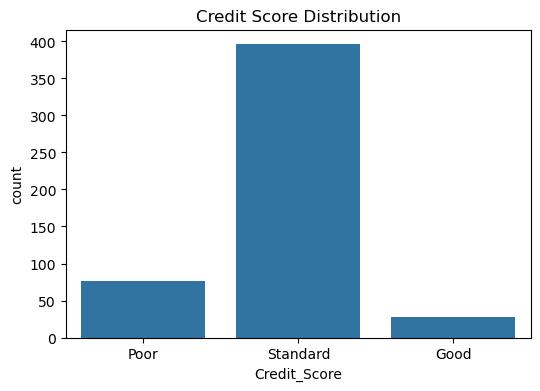

In [7]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Credit_Score",
    data=df
)

plt.title("Credit Score Distribution")

plt.show()

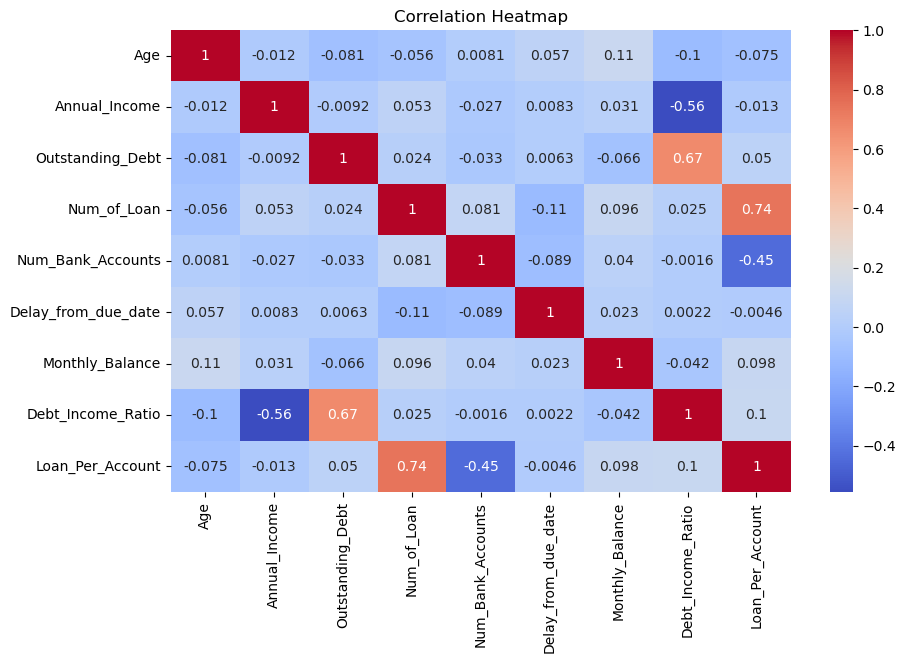

In [8]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [9]:
le = LabelEncoder()

df["Credit_Score"] = le.fit_transform(
    df["Credit_Score"]
)

df.head()

,Age,Annual_Income,Outstanding_Debt,Num_of_Loan,Num_Bank_Accounts,Delay_from_due_date,Monthly_Balance,Credit_Score,Debt_Income_Ratio,Loan_Per_Account
0,56,24000,10478,1,5,11,3827,1,0.436565,0.166667
1,46,90588,45162,3,5,1,6372,2,0.498537,0.500000
2,32,121042,19262,4,6,5,6095,2,0.159134,0.571429
3,60,113610,4432,0,7,16,9576,2,0.039010,0.000000
4,25,140420,29721,4,7,2,614,2,0.211656,0.500000


In [10]:
X = df.drop("Credit_Score", axis=1)

y = df["Credit_Score"]

print(X.shape)
print(y.shape)

(500, 9)
(500,)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(400, 9)
(100, 9)


In [12]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [13]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

print(
    "Accuracy:",
    accuracy_score(y_test, lr_pred)
)

Accuracy: 0.94


In [14]:
dt = DecisionTreeClassifier(
    max_depth=6,
    random_state=42
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print(
    "Accuracy:",
    accuracy_score(y_test, dt_pred)
)

Accuracy: 0.98


In [15]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print(
    "Accuracy:",
    accuracy_score(y_test, rf_pred)
)

Accuracy: 0.97


In [16]:
print("Logistic Regression")

print(
    classification_report(
        y_test,
        lr_pred
    )
)

print("Decision Tree")

print(
    classification_report(
        y_test,
        dt_pred
    )
)

print("Random Forest")

print(
    classification_report(
        y_test,
        rf_pred
    )
)

Logistic Regression
              precision    recall  f1-score   support

           0       0.75      0.50      0.60         6
           1       1.00      0.87      0.93        15
           2       0.94      0.99      0.96        79

    accuracy                           0.94       100
   macro avg       0.90      0.78      0.83       100
weighted avg       0.94      0.94      0.94       100

Decision Tree
              precision    recall  f1-score   support

           0       0.83      0.83      0.83         6
           1       1.00      1.00      1.00        15
           2       0.99      0.99      0.99        79

    accuracy                           0.98       100
   macro avg       0.94      0.94      0.94       100
weighted avg       0.98      0.98      0.98       100

Random Forest
              precision    recall  f1-score   support

           0       1.00      0.67      0.80         6
           1       1.00      0.93      0.97        15
           2       0.96    

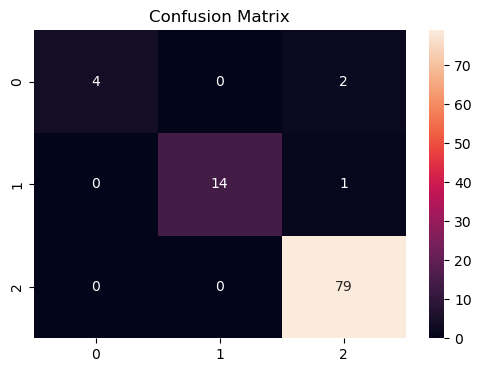

In [17]:
cm = confusion_matrix(
    y_test,
    rf_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title(
    "Confusion Matrix"
)

plt.show()